# Experiment: Key Tests Long-Run Corner Comparison

This notebook compares the **current** and **reference** CMASS inference pipelines inside the isolated `key_tests` workspace. It reads the four formal compare runs, aligns parameter order, generates overlaid corner plots, and saves PNG artifacts under `output/figures/`.


## Notes

- Both pipelines in this notebook use data from `/Users/liurongfu/Work/CMASS_lens_project/data`.
- The formal compare mode is now a long run: `10000` requested steps with `discard = 2000`.
- The **reference** pipeline stores the final two parameters in legacy order `(loga, theta0)`. This notebook reorders them to the current order `(theta0, loga)` before plotting.
- The last parameter is labeled `log a`, with the model relation `a = 10**loga`.
- Older `80`-step compare outputs were archived under `output/archive/compare_80step/` and are not used here.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

WORKSPACE_ROOT = Path('/Users/liurongfu/Work/CMASS_lens_project/key_tests')
FIGURES_DIR = WORKSPACE_ROOT / 'output' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TARGET_ORDER = ['mu5_0', 'beta5', 'xi5', 'sigma5', 'mu_gamma_0', 'beta_gamma', 'xi_gamma', 'sigma_gamma', 'mu_zs', 'sigma_zs', 'theta0', 'loga']
LABELS = [r'$\mu_{5,0}$', r'$\beta_5$', r'$\xi_5$', r'$\sigma_5$', r'$\mu_\gamma$', r'$\beta_\gamma$', r'$\xi_\gamma$', r'$\sigma_\gamma$', r'$\mu_s$', r'$\sigma_s$', r'$\theta_0$', r'$\log a$']
COMPARE_SUMMARIES = {
    'sersic': {
        'current': WORKSPACE_ROOT / 'output' / 'current' / 'sersic' / 'compare' / 'current_run_summary.json',
        'reference': WORKSPACE_ROOT / 'output' / 'reference' / 'sersic' / 'compare' / 'reference_run_summary.json',
    },
    'devauc': {
        'current': WORKSPACE_ROOT / 'output' / 'current' / 'devauc' / 'compare' / 'current_run_summary.json',
        'reference': WORKSPACE_ROOT / 'output' / 'reference' / 'devauc' / 'compare' / 'reference_run_summary.json',
    },
}


In [3]:
def load_summary(path: Path) -> dict[str, object]:
    return json.loads(path.read_text(encoding='utf-8'))


def reorder_samples(samples: np.ndarray, source_order: list[str], target_order: list[str]) -> np.ndarray:
    source_index = {name: index for index, name in enumerate(source_order)}
    return samples[:, [source_index[name] for name in target_order]]


def load_compare_dataset(summary_path: Path) -> dict[str, object]:
    summary = load_summary(summary_path)
    backend = emcee.backends.HDFBackend(str(Path(str(summary['chain_path']))), read_only=True)
    discard = int(summary['discard'])
    samples = backend.get_chain(flat=True, discard=discard)
    log_prob = backend.get_log_prob(flat=True, discard=discard)
    source_order = list(summary['parameter_order'])
    if source_order != TARGET_ORDER:
        samples = reorder_samples(samples, source_order, TARGET_ORDER)
    return {
        'summary': summary,
        'samples': samples,
        'log_prob': log_prob,
        'raw_steps': int(backend.iteration),
        'flat_samples': int(samples.shape[0]),
        'median_log_prob': float(np.median(log_prob)),
    }


def plot_overlay(profile_name: str, datasets: dict[str, dict[str, object]]) -> Path:
    current = datasets['current']
    reference = datasets['reference']
    fig = corner.corner(
        current['samples'],
        labels=LABELS,
        color='C0',
        show_titles=True,
        title_fmt='.2f',
        quantiles=[0.16, 0.5, 0.84],
        plot_datapoints=False,
        levels=[0.68, 0.95],
        smooth=0.7,
    )
    corner.corner(
        reference['samples'],
        labels=LABELS,
        color='C1',
        show_titles=False,
        quantiles=[0.16, 0.5, 0.84],
        plot_datapoints=False,
        levels=[0.68, 0.95],
        smooth=0.7,
        fig=fig,
    )
    legend_handles = [
        Line2D([0], [0], color='C0', lw=2, label='Current pipeline'),
        Line2D([0], [0], color='C1', lw=2, label='Reference pipeline'),
    ]
    fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), frameon=False)
    fig.suptitle(
        f"{profile_name} compare corner (current vs reference)\n"
        f"discard={current['summary']['discard']} | current steps={current['raw_steps']} | reference steps={reference['raw_steps']}",
        fontsize=18,
        y=1.02,
    )
    output_path = FIGURES_DIR / f"{profile_name}_compare_corner.png"
    fig.savefig(output_path, dpi=220, bbox_inches='tight')
    return fig


In [4]:
loaded = {}
summary_rows = []
for profile_name, implementations in COMPARE_SUMMARIES.items():
    loaded[profile_name] = {}
    for implementation_name, summary_path in implementations.items():
        dataset = load_compare_dataset(summary_path)
        loaded[profile_name][implementation_name] = dataset
        summary_rows.append({
            'profile': profile_name,
            'implementation': implementation_name,
            'requested_steps': dataset['summary']['requested_steps'],
            'warmup': dataset['summary']['warmup'],
            'discard': dataset['summary']['discard'],
            'raw_steps': dataset['raw_steps'],
            'flat_samples': dataset['flat_samples'],
            'median_log_prob': round(dataset['median_log_prob'], 6),
            'chain_path': dataset['summary']['chain_path'],
            'summary_path': str(summary_path),
        })
summary_rows


[{'profile': 'sersic',
  'implementation': 'current',
  'requested_steps': 10000,
  'warmup': 2000,
  'discard': 2000,
  'raw_steps': 10000,
  'flat_samples': 192000,
  'median_log_prob': -29.858172,
  'chain_path': '/Users/liurongfu/Work/CMASS_lens_project/key_tests/output/current/sersic/compare/sersic/20260308_223036_sersic_compare/chain.h5',
  'summary_path': '/Users/liurongfu/Work/CMASS_lens_project/key_tests/output/current/sersic/compare/current_run_summary.json'},
 {'profile': 'sersic',
  'implementation': 'reference',
  'requested_steps': 10000,
  'warmup': 2000,
  'discard': 2000,
  'raw_steps': 10000,
  'flat_samples': 192000,
  'median_log_prob': -16.698972,
  'chain_path': '/Users/liurongfu/Work/CMASS_lens_project/key_tests/output/reference/sersic/compare/reference_chain.h5',
  'summary_path': '/Users/liurongfu/Work/CMASS_lens_project/key_tests/output/reference/sersic/compare/reference_run_summary.json'},
 {'profile': 'devauc',
  'implementation': 'current',
  'requested_ste

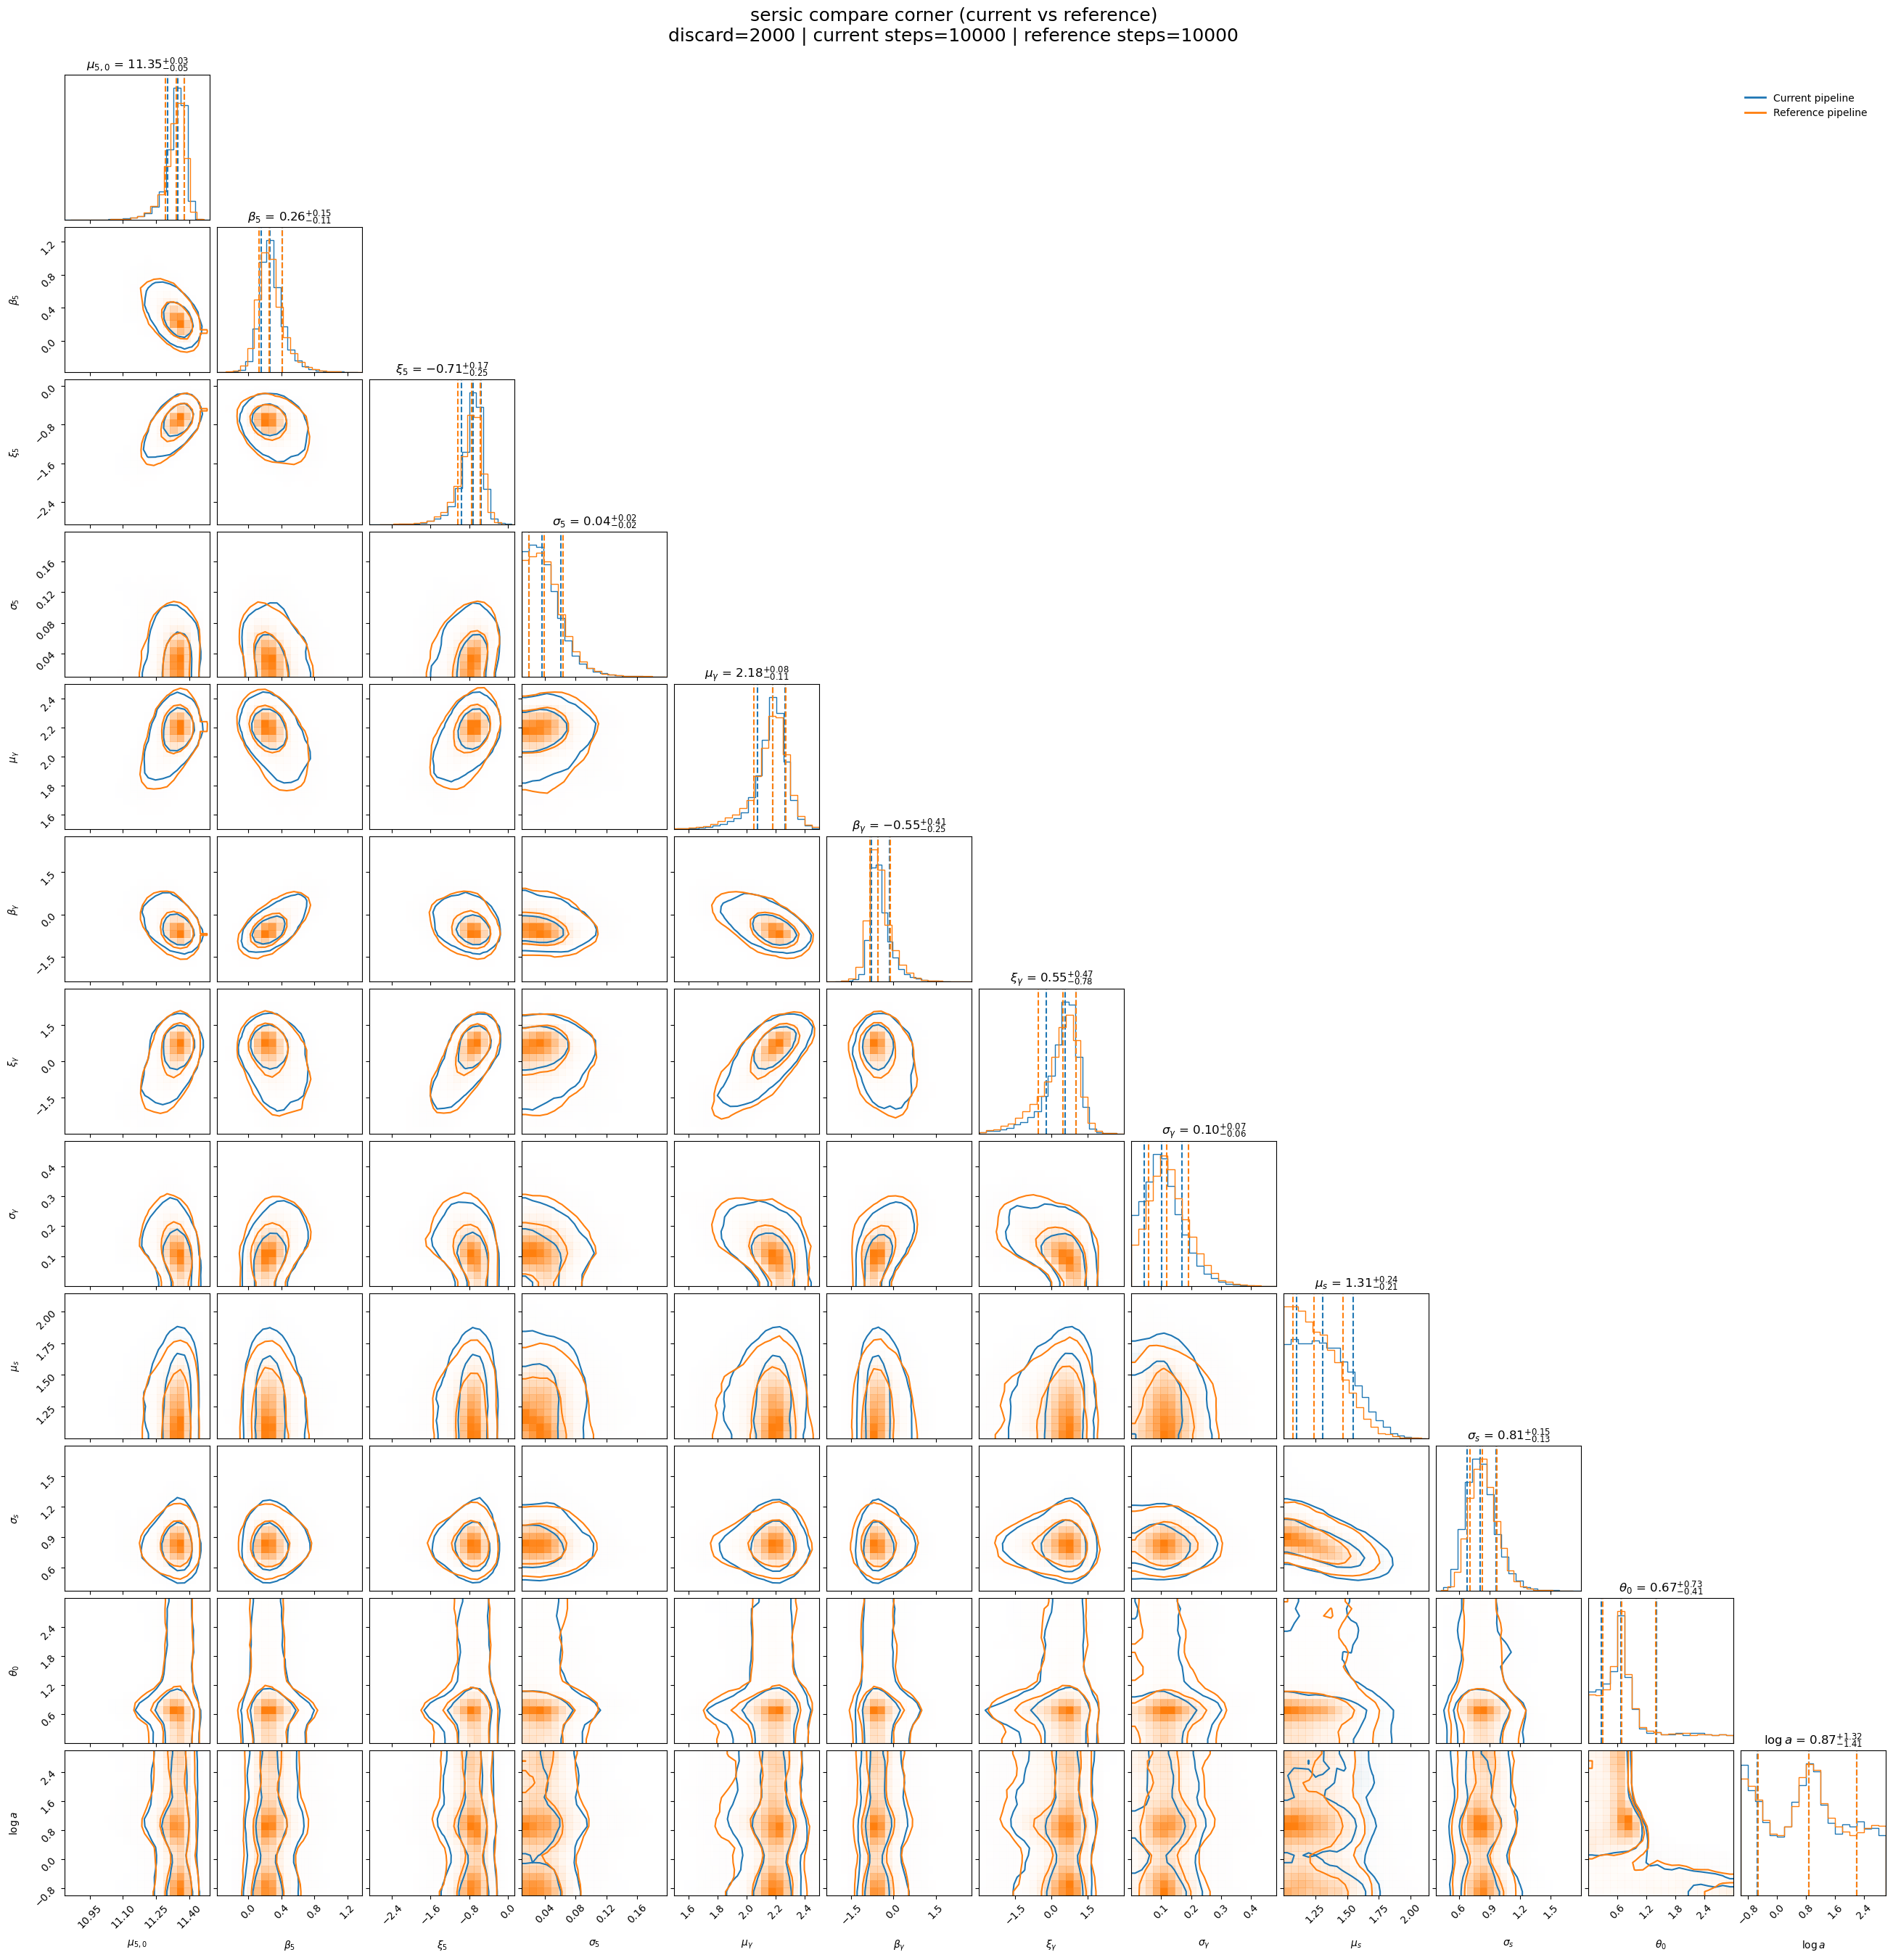

In [7]:
sersic_figure = plot_overlay('sersic', loaded['sersic'])
# sersic_figure


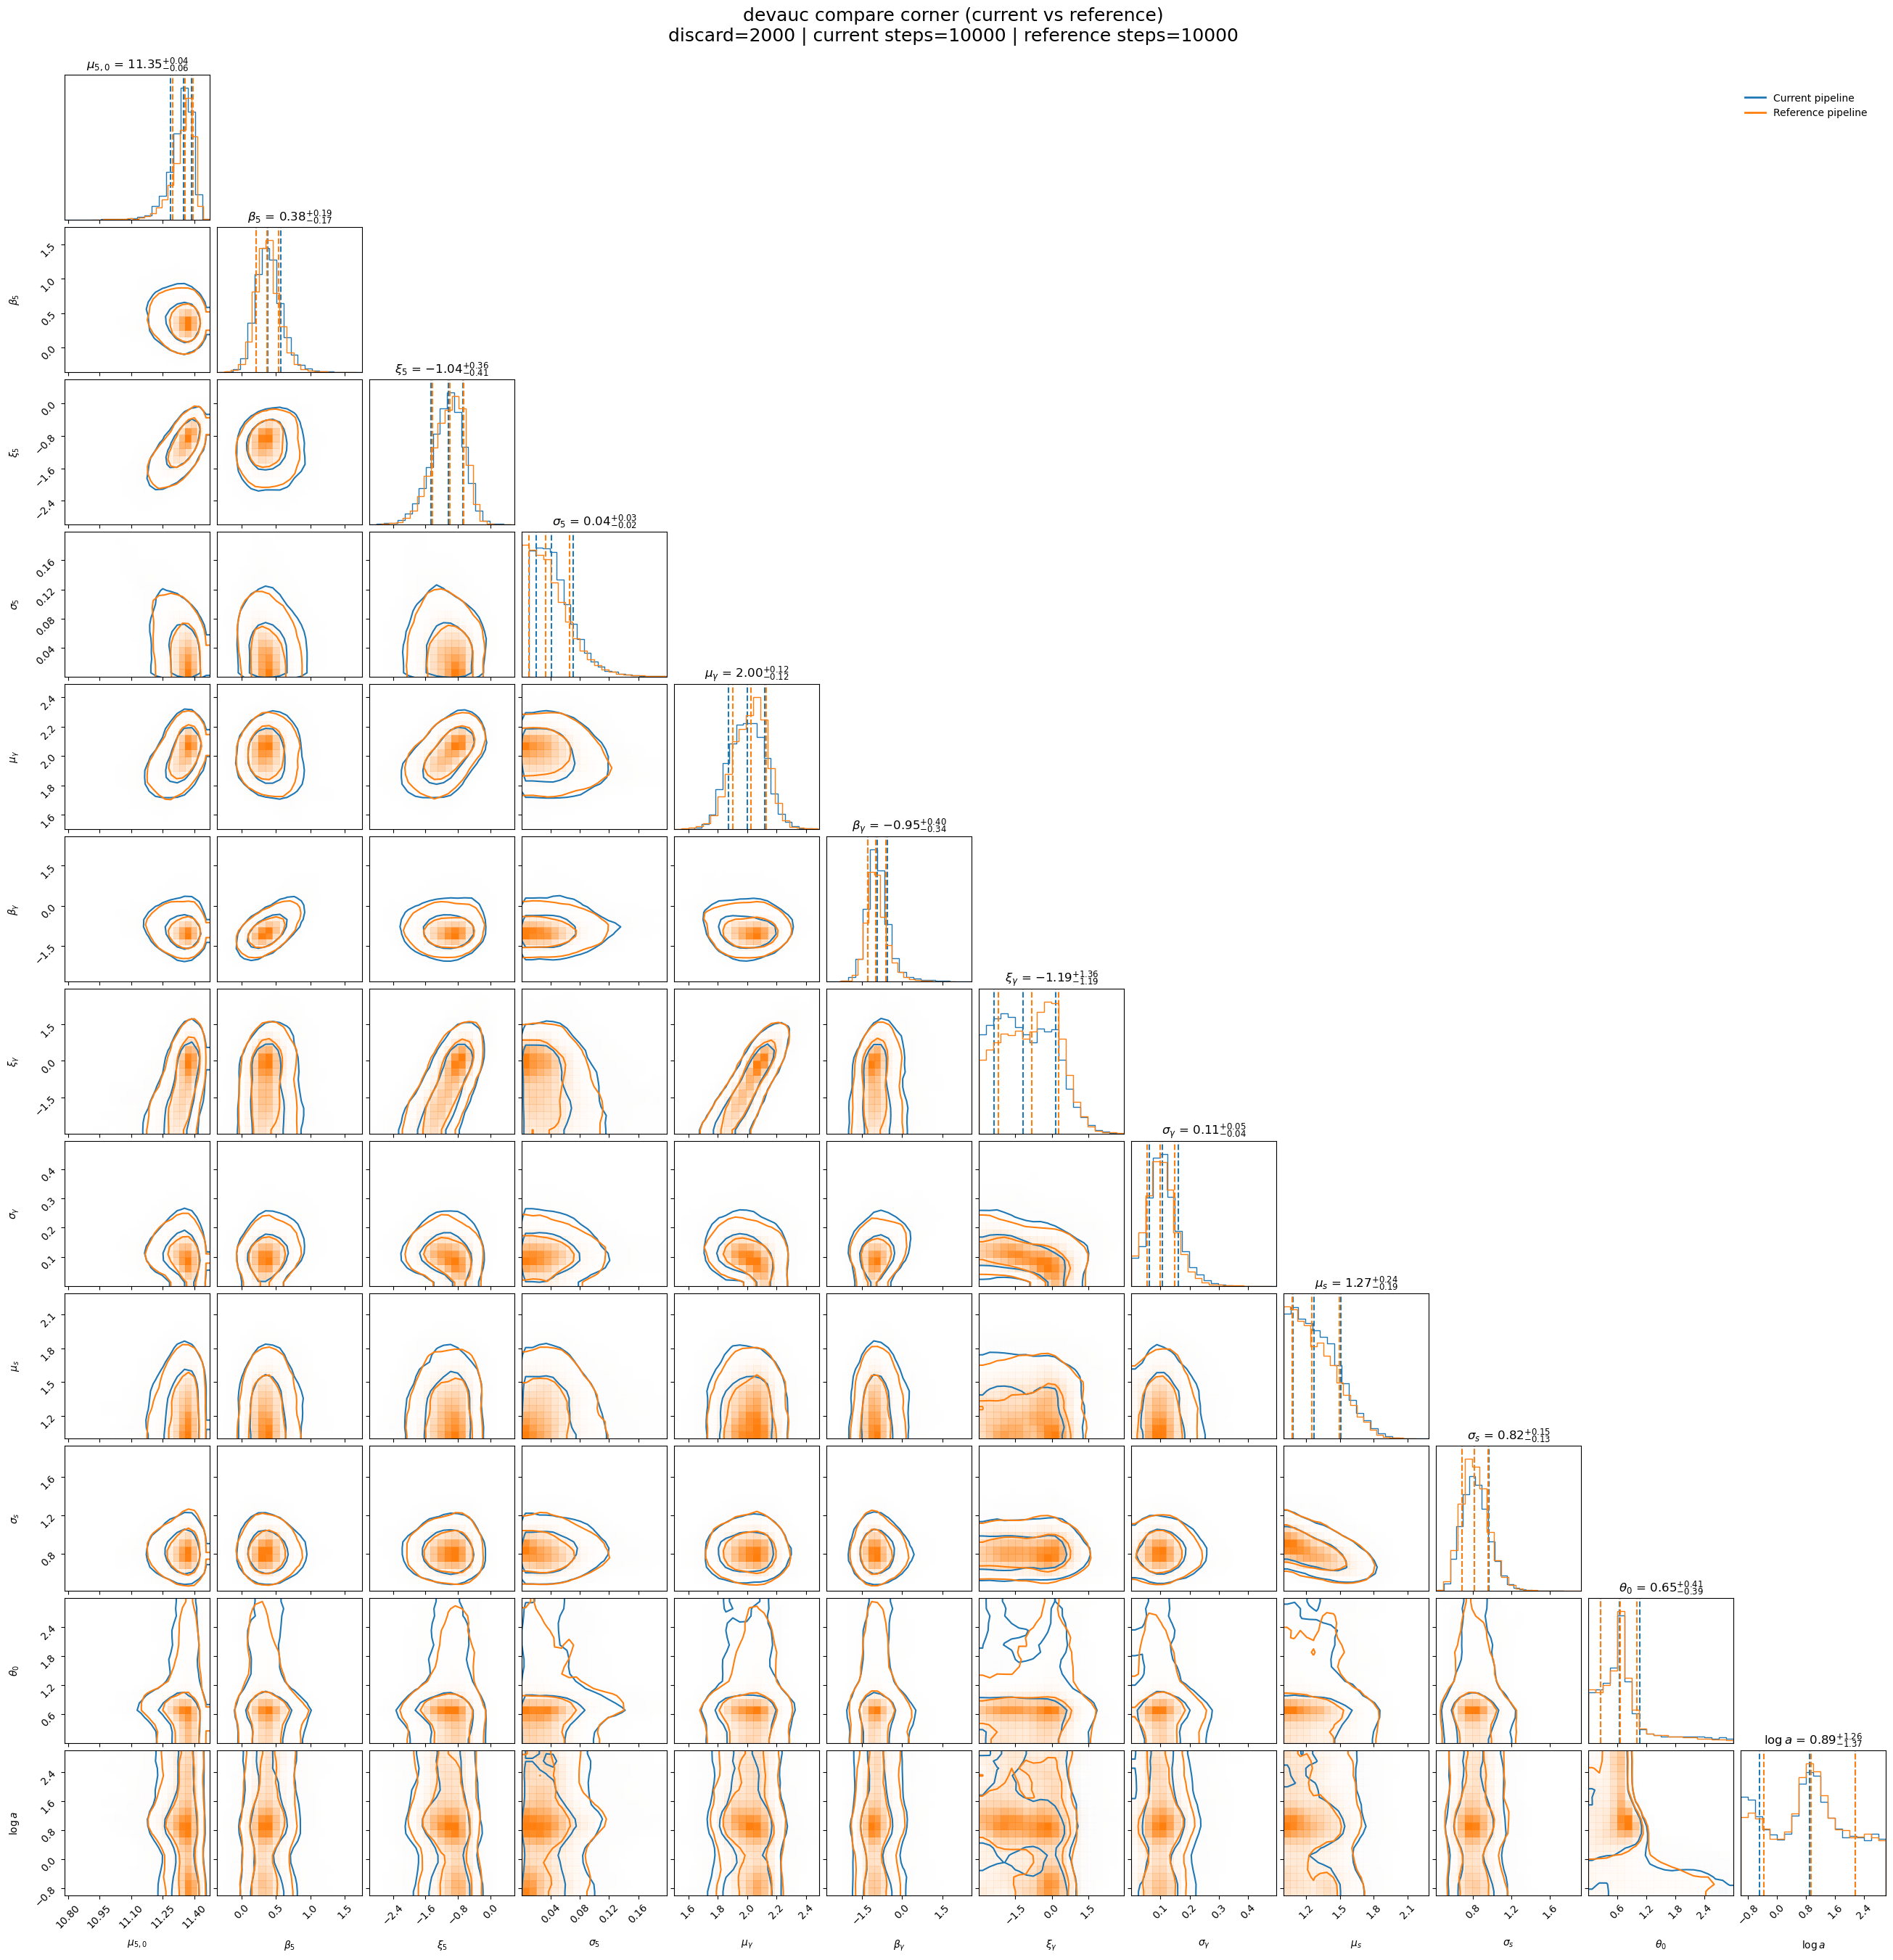

In [8]:
devauc_figure = plot_overlay('devauc', loaded['devauc'])
# devauc_figure


## Output files

- `output/figures/sersic_compare_corner.png`
- `output/figures/devauc_compare_corner.png`
- Compare summaries remain in `output/current/*/compare/` and `output/reference/*/compare/`.
- Archived `80`-step compare artifacts remain under `output/archive/compare_80step/`.
